In [3]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

print(df.shape)
print(df.columns)

(10000, 14)
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [17]:
df = df.drop(['UDI', 'Product ID'], axis=1, errors='ignore')

print(df.head())
print(df.shape)

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  
(10000, 12)


In [7]:
# Check target variable

print(df['Machine failure'].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [8]:
# Check data types

print(df.dtypes)

Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [9]:
# Convert Type column to numeric values

df['Type'] = df['Type'].map({
    'L': 0,
    'M': 1,
    'H': 2
})

print(df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


In [10]:
print(df['Type'].value_counts())

Type
0    6000
1    2997
2    1003
Name: count, dtype: int64


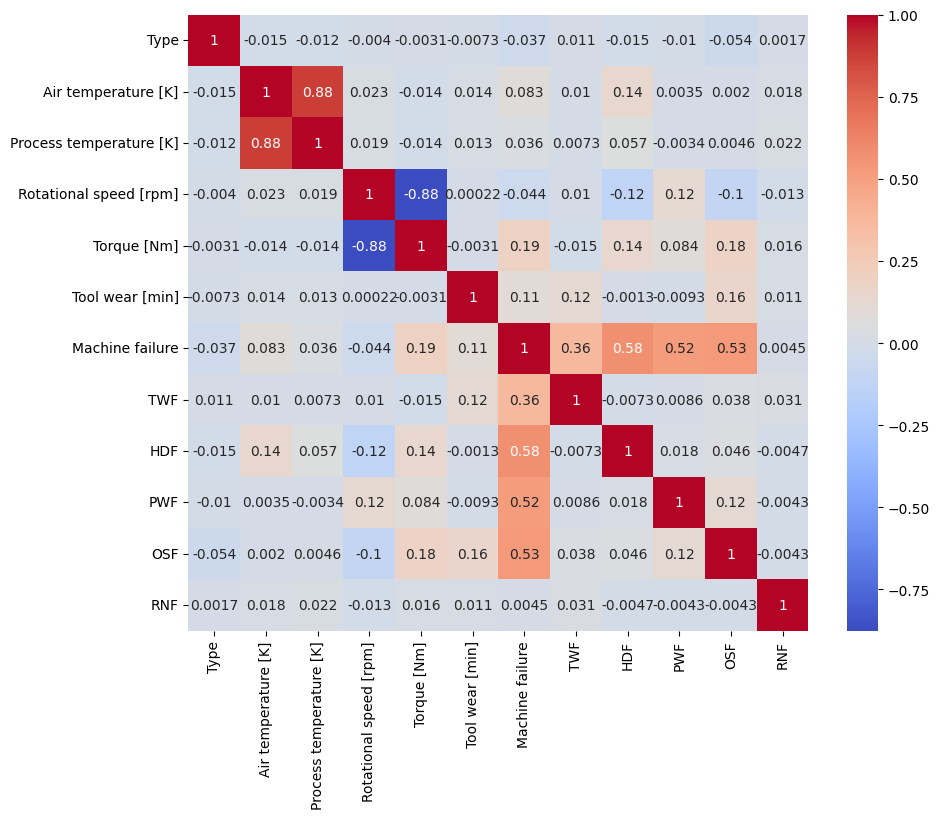

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.999


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



                    Feature  Importance
7                       HDF    0.305343
9                       OSF    0.213352
8                       PWF    0.176225
6                       TWF    0.109435
4               Torque [Nm]    0.076182
3    Rotational speed [rpm]    0.050486
5           Tool wear [min]    0.035356
1       Air temperature [K]    0.017053
2   Process temperature [K]    0.012277
0                      Type    0.003586
10                      RNF    0.000705


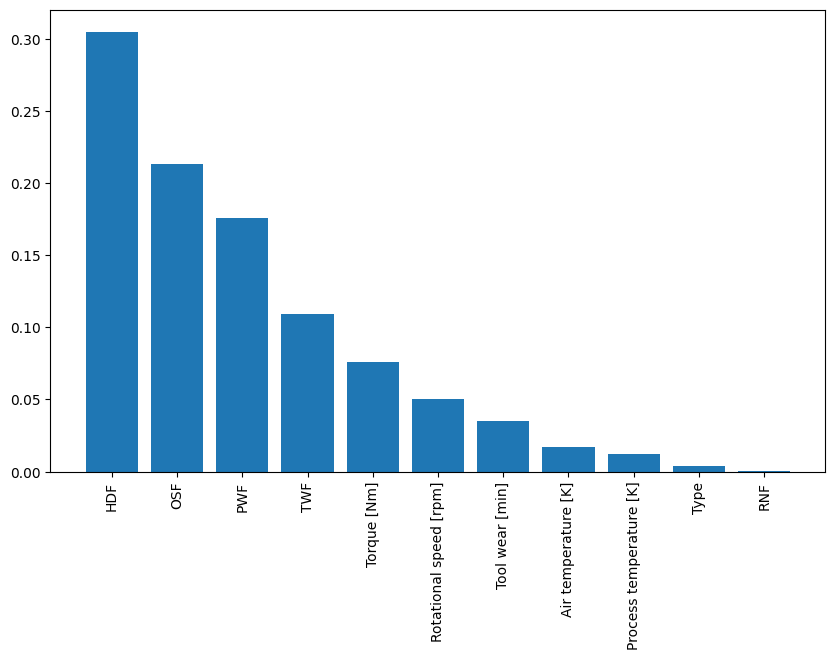

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

features = features.sort_values(
    by='Importance',
    ascending=False
)

print(features)

plt.figure(figsize=(10,6))
plt.bar(features['Feature'], features['Importance'])
plt.xticks(rotation=90)
plt.show()

In [22]:
# Rolling Mean
df['rpm_roll_mean'] = df['Rotational speed [rpm]'].rolling(window=10).mean()

# Rolling Standard Deviation
df['rpm_roll_std'] = df['Rotational speed [rpm]'].rolling(window=10).std()

# Rolling Variance
df['rpm_roll_var'] = df['Rotational speed [rpm]'].rolling(window=10).var()

In [23]:
'Air temperature [K]'
'Process temperature [K]'
'Torque [Nm]'
'Tool wear [min]'

'Tool wear [min]'

In [24]:
df['torque_roll_mean'] = df['Torque [Nm]'].rolling(10).mean()
df['torque_roll_std'] = df['Torque [Nm]'].rolling(10).std()
df['torque_roll_var'] = df['Torque [Nm]'].rolling(10).var()

In [25]:
df = df.dropna()

In [26]:
df[['rpm_roll_mean',
    'rpm_roll_std',
    'rpm_roll_var']].head()

,rpm_roll_mean,rpm_roll_std,rpm_roll_var
9,1521.6,113.060652,12782.711111
10,1544.7,140.100004,19628.011111
11,1546.2,138.545460,19194.844444
12,1530.3,153.055582,23426.011111
13,1561.2,162.150684,26292.844444


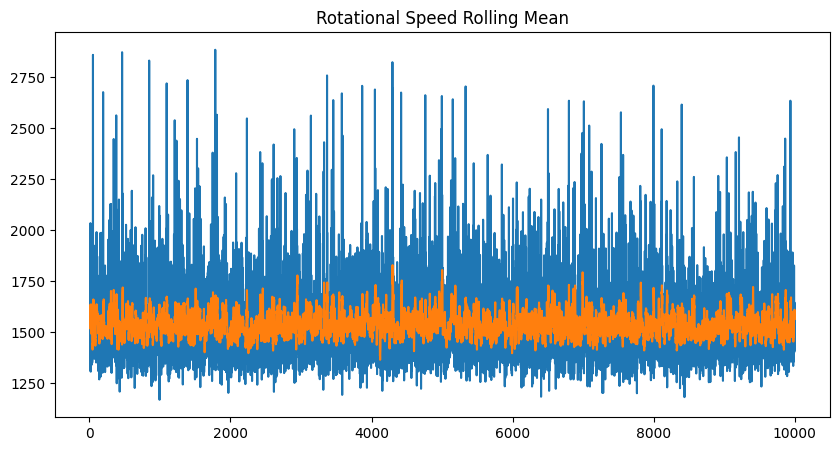

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Rotational speed [rpm]'])
plt.plot(df['rpm_roll_mean'])
plt.title('Rotational Speed Rolling Mean')
plt.show()